In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")

# Aperçu
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           100000 non-null  object 
 1   AGE_CLI      99524 non-null   float64
 2   B_MAT        98620 non-null   float64
 3   B_RESMAT     98620 non-null   float64
 4   CLASSACT     100000 non-null  int64  
 5   CSP          97522 non-null   float64
 6   DARRET       100000 non-null  int64  
 7   E_EAD        98620 non-null   float64
 8   E_OFF        98620 non-null   float64
 9   E_ONB        98620 non-null   float64
 10  MREVAU       99954 non-null   float64
 11  MREVNU       99954 non-null   float64
 12  MREVTOT      99954 non-null   float64
 13  MTECH        100000 non-null  float64
 14  NBIMP        100000 non-null  int64  
 15  NB_ECH       100000 non-null  int64  
 16  produit      100000 non-null  object 
 17  RA           100000 non-null  float64
 18  Tx           95114 non-nu

In [2]:
cols_to_drop = [
    "Unnamed: 19",
    "MREVAU",
    "MREVNU"
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


In [3]:
# DARRET au format YYYYMM → datetime
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str) + "01",
    format="%Y%m%d",
    errors="coerce"
)

df["DARRET"].isna().mean()


np.float64(0.0)

In [4]:
# Vérification de redondance
df[["E_EAD", "E_ONB"]].describe()

,E_EAD,E_ONB
count,98620.000000,98620.000000
mean,998.009810,998.009810
std,5744.202071,5744.202071
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.190000,0.190000
max,267563.810000,267563.810000


In [5]:
#ATTENTION : 

# Si quasi identiques :
df["EAD"] = df["E_EAD"]

df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")


In [6]:
# EAD strictement positif
df = df[df["EAD"] > 0]

# RA cohérent
df["RA"] = df["RA"].fillna(0)
df = df[df["RA"] <= df["EAD"]]


In [7]:
df["EAD"].describe()

count      7520.000000
mean      11429.963249
std       17215.355070
min           0.010000
25%        2201.775000
50%        5683.625000
75%       13517.565000
max      267563.810000
Name: EAD, dtype: float64

In [8]:
cat_cols = ["CLASSACT", "CSP", "produit"]

for c in cat_cols:
    df[c] = df[c].astype("category")


In [9]:
# Imputation par médiane du produit
df["Tx"] = df.groupby("produit")["Tx"].transform(
    lambda x: x.fillna(x.median())
)

# Si jamais un produit a tout NA (rare)
df["Tx"] = df["Tx"].fillna(df["Tx"].median())


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\1538751272.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Tx"] = df.groupby("produit")["Tx"].transform(


In [10]:
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")


In [11]:
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())


In [12]:
# Âge du prêt en mois
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]

# Contrôles
df["AGE_PRET"].describe()


count    7520.000000
mean       29.542287
std        32.059375
min       -66.000000
25%         9.000000
50%        21.000000
75%        39.000000
max       299.000000
Name: AGE_PRET, dtype: float64

In [13]:
# Âge négatif ou incohérent = erreur
df = df[df["AGE_PRET"] >= 0]
df = df[df["AGE_PRET"] <= df["B_MAT"]]

In [14]:
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

In [15]:
df["HORIZON_RES"].describe()

count    7473.000000
mean       53.632811
std        43.754083
min         1.000000
25%        21.000000
50%        42.000000
75%        71.000000
max       276.000000
Name: HORIZON_RES, dtype: float64

cash flow du cpital a la date d'arretee

In [16]:
df["CF_CAP_OBS"] = df["RA"].fillna(0)

In [17]:
df["ER_obs"] = df["RA"] / df["EAD"]

# Nettoyage
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)


In [18]:
df["ER_obs"].describe()

count    7473.000000
mean        0.263071
std         0.282876
min         0.000000
25%         0.036237
50%         0.140981
75%         0.432059
max         1.000000
Name: ER_obs, dtype: float64

In [19]:
df["FLAG_ER"] = (df["RA"] > 0).astype(int)


In [20]:
df["FLAG_ER"].describe()

count    7473.000000
mean        0.897096
std         0.303854
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: FLAG_ER, dtype: float64

In [21]:
df["EAD_POST"] = df["EAD"] - df["RA"]
df["EAD_POST"] = df["EAD_POST"].clip(lower=0)
df["EAD_POST"].describe()

count      7473.000000
mean       9711.866313
std       16710.148921
min           0.000000
25%        1249.380000
50%        4042.060000
75%       10795.360000
max      265929.160000
Name: EAD_POST, dtype: float64

In [22]:
# ER moyen par âge du prêt
er_by_age = (
    df.groupby("AGE_PRET")["ER_obs"]
    .mean()
    .reset_index()
)

er_by_age.head(15)


,AGE_PRET,ER_obs
0,0.0,0.343086
1,1.0,0.417501
2,2.0,0.339477
3,3.0,0.247252
4,4.0,0.287135
5,5.0,0.259406
6,6.0,0.302490
7,7.0,0.314570
8,8.0,0.290262
9,9.0,0.287570


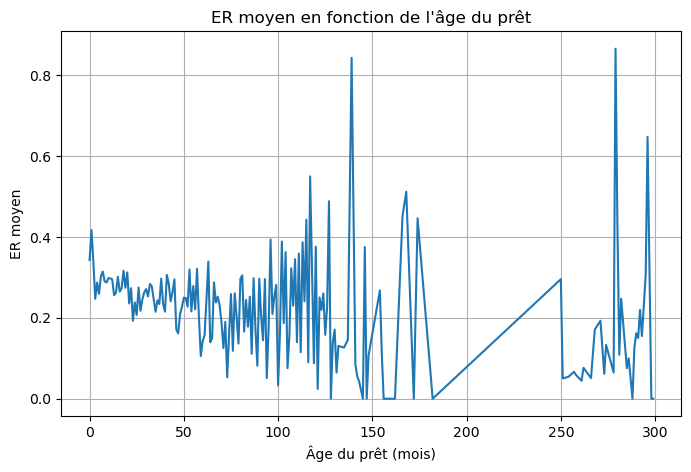

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(er_by_age["AGE_PRET"], er_by_age["ER_obs"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("ER moyen")
plt.title("ER moyen en fonction de l'âge du prêt")
plt.grid(True)
plt.show()


In [24]:
flag_by_age = (
    df.groupby("AGE_PRET")["FLAG_ER"]
    .mean()
    .reset_index()
)

flag_by_age.head()


,AGE_PRET,FLAG_ER
0,0.0,0.916667
1,1.0,0.865854
2,2.0,0.892857
3,3.0,0.861702
4,4.0,0.920635


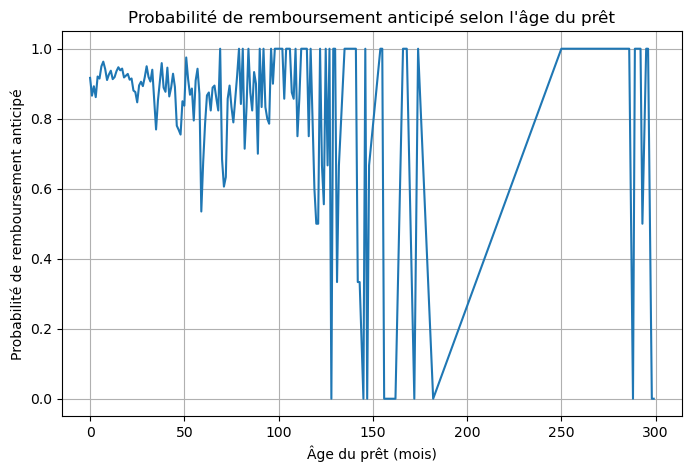

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(flag_by_age["AGE_PRET"], flag_by_age["FLAG_ER"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("Probabilité de remboursement anticipé")
plt.title("Probabilité de remboursement anticipé selon l'âge du prêt")
plt.grid(True)
plt.show()


In [26]:
er_by_product = (
    df.groupby("produit")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
    .sort_values("taux_ER", ascending=False)
)

er_by_product


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\2468332605.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("produit")


,taux_ER,ER_moyen,n_obs
produit,,,
AMO,0.897481,0.263301,7462
AR,0.636364,0.106918,11


In [27]:
df["Tx_bin"] = pd.qcut(df["Tx"], q=4, duplicates="drop")

er_by_tx = (
    df.groupby("Tx_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_tx


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\3312823585.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tx_bin")


,taux_ER,ER_moyen,n_obs
Tx_bin,,,
"(-1.501, 2.098]",0.878270,0.298815,1873
"(2.098, 2.181]",0.907023,0.272407,2022
"(2.181, 2.256]",0.895227,0.247127,1718
"(2.256, 2.786]",0.906989,0.231656,1860


In [28]:
df["B_RESMAT_bin"] = pd.cut(df["B_RESMAT"], bins=10)

er_by_resmat = (
    df.groupby("B_RESMAT_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_resmat


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\3350780450.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("B_RESMAT_bin")


,taux_ER,ER_moyen,n_obs
B_RESMAT_bin,,,
"(0.725, 28.5]",0.853803,0.318256,2524
"(28.5, 56.0]",0.925676,0.231274,2368
"(56.0, 83.5]",0.916667,0.227901,1044
"(83.5, 111.0]",0.905455,0.207655,550
"(111.0, 138.5]",0.907445,0.261481,497
"(138.5, 166.0]",0.914286,0.269188,245
"(166.0, 193.5]",0.943478,0.282716,230
"(193.5, 221.0]",0.600000,0.158878,10
"(221.0, 248.5]",1.000000,0.157061,2


In [29]:
df

,ID,AGE_CLI,B_MAT,B_RESMAT,CLASSACT,CSP,DARRET,E_OFF,MREVTOT,MTECH,...,Tx,EAD,AGE_PRET,HORIZON_RES,CF_CAP_OBS,ER_obs,FLAG_ER,EAD_POST,Tx_bin,B_RESMAT_bin
71,a000072,44.0,72.0,43.0,1,45.0,2019-01-01,0.0,2502.0,30.03,...,2.302021,1158.68,29.0,43,150.00,0.129458,1,1008.68,"(2.256, 2.786]","(28.5, 56.0]"
73,a000074,74.0,49.0,34.0,1,70.0,2019-01-01,0.0,1740.0,121.38,...,2.037189,3570.76,15.0,34,286.84,0.080330,1,3283.92,"(-1.501, 2.098]","(28.5, 56.0]"
123,a000124,48.0,36.0,11.0,1,56.0,2019-01-01,0.0,1799.0,35.70,...,2.115002,204.12,25.0,11,157.53,0.771752,1,46.59,"(2.098, 2.181]","(0.725, 28.5]"
125,a000126,51.0,72.0,48.0,1,52.0,2019-01-01,0.0,2507.0,452.08,...,2.083425,18999.02,24.0,48,489.12,0.025744,1,18509.90,"(-1.501, 2.098]","(28.5, 56.0]"
135,a000136,55.0,48.0,35.0,1,52.0,2019-01-01,0.0,1754.0,190.18,...,2.180607,5982.14,13.0,35,412.54,0.068962,1,5569.60,"(2.098, 2.181]","(28.5, 56.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99952,a099953,24.0,22.0,17.0,1,60.0,2023-12-01,0.0,2048.0,195.07,...,2.472203,3306.49,5.0,17,0.00,0.000000,0,3306.49,"(2.256, 2.786]","(0.725, 28.5]"
99961,a099962,65.0,182.0,170.0,1,70.0,2023-12-01,0.0,1584.0,480.29,...,2.179428,51781.65,12.0,170,9990.00,0.192925,1,41791.65,"(2.098, 2.181]","(166.0, 193.5]"
99980,a099981,44.0,61.0,32.0,1,64.0,2023-12-01,0.0,1615.0,115.03,...,2.058708,2973.14,29.0,32,1500.00,0.504517,1,1473.14,"(-1.501, 2.098]","(28.5, 56.0]"
99988,a099989,68.0,61.0,15.0,1,70.0,2023-12-01,0.0,3401.0,196.53,...,2.180607,2498.03,46.0,15,1000.00,0.400315,1,1498.03,"(2.098, 2.181]","(0.725, 28.5]"


In [30]:
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'ER_obs', 'FLAG_ER',
       'EAD_POST', 'Tx_bin', 'B_RESMAT_bin'],
      dtype='object')

In [31]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


cat_cols = ['CLASSACT', 'CSP', 'produit', 'Tx_bin', 'B_RESMAT_bin']
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

features = ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'FLAG_ER',
       'EAD_POST', 'Tx_bin', 'B_RESMAT_bin']

X = df[features].fillna(0)  # Matrice explicatives


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 0. CRÉER ER proprement
df['ER_obs'] = df['RA'] / df['EAD']
df['ER_obs'] = df['ER_obs'].clip(0, 1)

# 1. FEATURES SANS RISQUE (SEULEMENT colonnes NUMÉRIQUES PROUVÉES)
safe_features = ['AGE_CLI', 'B_MAT', 'B_RESMAT', 'E_OFF', 'MREVTOT', 
                'MTECH', 'NBIMP', 'NB_ECH', 'Tx', 'AGE_PRET', 'HORIZON_RES']

# AJOUTER CSP si encodé correctement
if 'CSP' in df.columns and df['CSP'].dtype in ['int64', 'float64']:
    safe_features.append('CSP')

X = df[safe_features].copy()
print("✅ X safe:", X.shape, "Colonnes:", X.columns.tolist())
print("✅ Tous numériques:", X.select_dtypes(include=[np.number]).shape == X.shape)

# 2. SPLIT + SCALE + FIT
y_er = df['ER_obs']
X_train, X_test, y_train_er, y_test_er = train_test_split(X, y_er, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train_er)
y_pred_er = linreg.predict(X_test_scaled)

# 3. RÉSULTATS
rmse = np.sqrt(mean_squared_error(y_test_er, y_pred_er))
r2 = r2_score(y_test_er, y_pred_er)
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ R²: {r2:.3f}")

print("\n🏆 Top features:")
coef_df = pd.DataFrame({
    'feature': safe_features, 
    'coef': linreg.coef_
}).sort_values('coef', key=abs, ascending=False)
print(coef_df.head())


✅ X safe: (7473, 12) Colonnes: ['AGE_CLI', 'B_MAT', 'B_RESMAT', 'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'Tx', 'AGE_PRET', 'HORIZON_RES', 'CSP']
✅ Tous numériques: True
✅ RMSE: 0.2744
✅ R²: 0.069

🏆 Top features:
    feature      coef
7    NB_ECH -0.079369
8        Tx -0.031619
5     MTECH -0.029598
6     NBIMP -0.019809
2  B_RESMAT  0.017893


In [33]:
print("Types après encodage:")
print(X.dtypes)

Types après encodage:
AGE_CLI        float64
B_MAT          float64
B_RESMAT       float64
E_OFF          float64
MREVTOT        float64
MTECH          float64
NBIMP            int64
NB_ECH           int64
Tx             float64
AGE_PRET       float64
HORIZON_RES      int64
CSP              int64
dtype: object


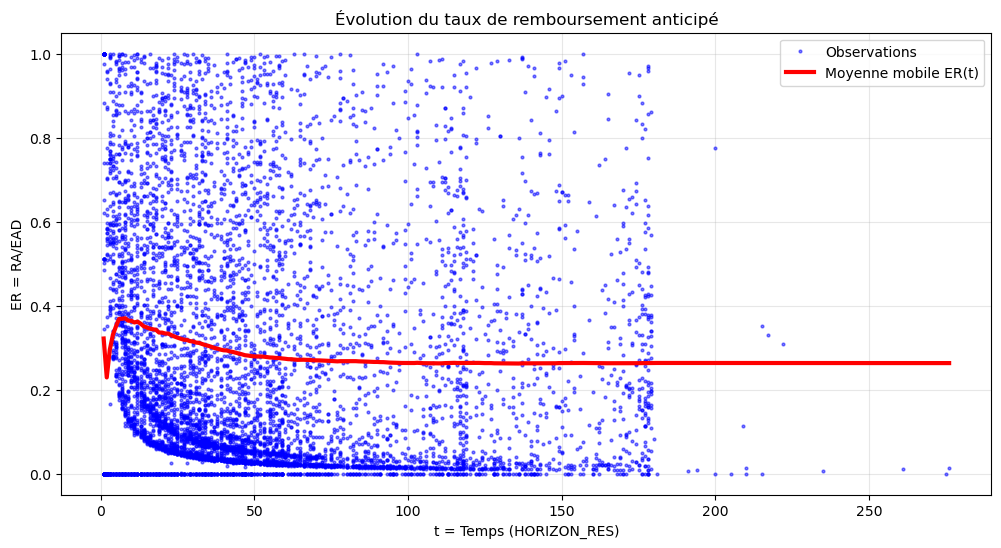

ER par quartile t:
                 mean       std  count
HORIZON_RES                           
Q1           0.333506  0.291742   1891
Q2           0.248723  0.276348   1898
Q3           0.225115  0.275434   1840
Q4           0.243483  0.275145   1844


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\196666514.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(quartiles)['ER'].agg(['mean','std','count']))


In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Calculer ER
df['ER'] = df['RA'] / df['EAD']
df['ER'] = df['ER'].clip(0, 1)

# 2. Choisir t (adaptez)
t = df['HORIZON_RES']  # ou NB_ECH ou AGE_PRET

# 3. TRACER ER(t)
plt.figure(figsize=(12, 6))

# Points avec smoothing
plt.plot(t, df['ER'], 'o', alpha=0.5, markersize=2, color='blue', label='Observations')

# Moyenne mobile (lissage)
t_sorted = np.sort(t.unique())
er_smooth = []
for ti in t_sorted:
    er_smooth.append(df[df[t.name] <= ti]['ER'].mean())

plt.plot(t_sorted, er_smooth, 'r-', linewidth=3, label='Moyenne mobile ER(t)')

plt.xlabel('t = Temps (HORIZON_RES)')
plt.ylabel('ER = RA/EAD')
plt.title('Évolution du taux de remboursement anticipé')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Tableau stats
print("ER par quartile t:")
quartiles = pd.qcut(t, 4, labels=['Q1','Q2','Q3','Q4'])
print(df.groupby(quartiles)['ER'].agg(['mean','std','count']))


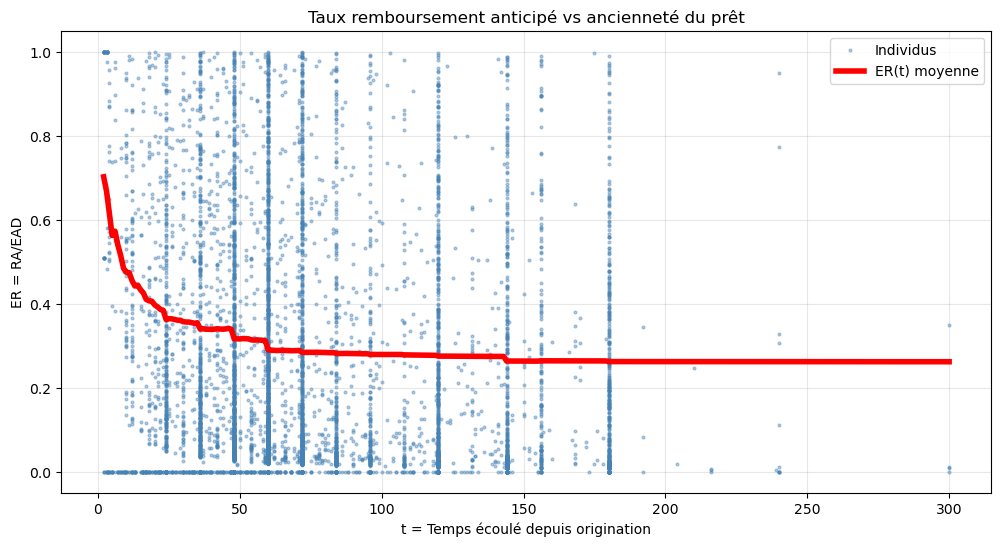

ER par tranche d'âge du prêt :


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\1338451694.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('t_bin')['ER'].agg(['mean', 'count']).round(3))


                 mean  count
t_bin                       
(1.702, 31.8]   0.358    843
(31.8, 61.6]    0.272   3042
(61.6, 91.4]    0.258   1344
(91.4, 121.2]   0.243    923
(121.2, 151.0]  0.163    719
(151.0, 180.8]  0.249    579
(180.8, 210.6]  0.139      5
(210.6, 240.4]  0.179     14
(240.4, 270.2]    NaN      0
(270.2, 300.0]  0.094      4


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Créer t = TEMPS ÉCOULÉ (pas restant !)
if 'MATURITE_TOTALE' in df.columns:
    df['t_ecoule'] = df['MATURITE_TOTALE'] - df['HORIZON_RES']
else:
    df['t_ecoule'] = df['NB_ECH']  # Alternative si pas de maturité totale

# 2. ER
df['ER'] = df['RA'] / df['EAD']
df['ER'] = df['ER'].clip(0, 1)

t = df['t_ecoule']

# 3. GRAPHIQUE ER(t_écoulé)
plt.figure(figsize=(12, 6))
plt.plot(t, df['ER'], 'o', alpha=0.4, markersize=2, color='steelblue', label='Individus')

# Lissage : moyenne mobile par t
t_sort = np.sort(t.unique())
er_smooth = [df[t <= ti]['ER'].mean() for ti in t_sort]
plt.plot(t_sort, er_smooth, 'red', linewidth=4, label='ER(t) moyenne')

plt.xlabel('t = Temps écoulé depuis origination')
plt.ylabel('ER = RA/EAD')
plt.title('Taux remboursement anticipé vs ancienneté du prêt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Stats
print("ER par tranche d'âge du prêt :")
df['t_bin'] = pd.cut(df['t_ecoule'], bins=10)
print(df.groupby('t_bin')['ER'].agg(['mean', 'count']).round(3))


RA nettoyé: 0.0 80000.0


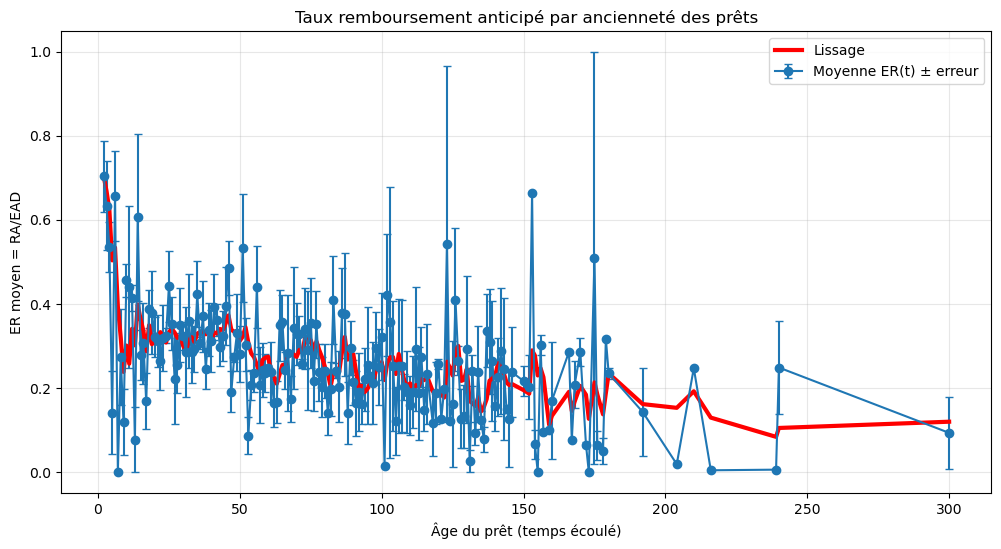

Aperçu :
   t_ecoule      mean  count
0         2  0.703285     20
1         3  0.633754     19
2         4  0.535315     26
3         5  0.141877      8
4         6  0.656189      9
5         7  0.000000      5
6         8  0.274097      9
7         9  0.119554      8
8        10  0.455807     47
9        11  0.440781      6


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. NETTOYER RA négatifs
df['RA_clean'] = df['RA'].clip(lower=0)  # RA ≥ 0
print("RA nettoyé:", df['RA_clean'].min(), df['RA_clean'].max())

# 2. ER correct
df['ER'] = df['RA_clean'] / df['EAD'].clip(lower=1)
df['ER'] = df['ER'].clip(upper=1)  # ER ≤ 100%

df['t_ecoule'] = df['NB_ECH']  # ou MATURITE_TOTALE - HORIZON_RES

# 2. AGRÉGER : Moyenne ER par âge du prêt (tous prêts confondus)
er_par_t = df.groupby('t_ecoule')['ER'].agg(['mean', 'std', 'count']).reset_index()
er_par_t['er_smooth'] = er_par_t['mean'].rolling(5, min_periods=1).mean()

# 3. TRACER (cohérent !)
plt.figure(figsize=(12, 6))
plt.errorbar(er_par_t['t_ecoule'], er_par_t['mean'], 
             yerr=er_par_t['std']/np.sqrt(er_par_t['count']), 
             fmt='o-', capsize=3, label='Moyenne ER(t) ± erreur')
plt.plot(er_par_t['t_ecoule'], er_par_t['er_smooth'], 'r-', linewidth=3, label='Lissage')

plt.xlabel('Âge du prêt (temps écoulé)')
plt.ylabel('ER moyen = RA/EAD')
plt.title('Taux remboursement anticipé par ancienneté des prêts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Aperçu :")
print(er_par_t[['t_ecoule', 'mean', 'count']].head(10))


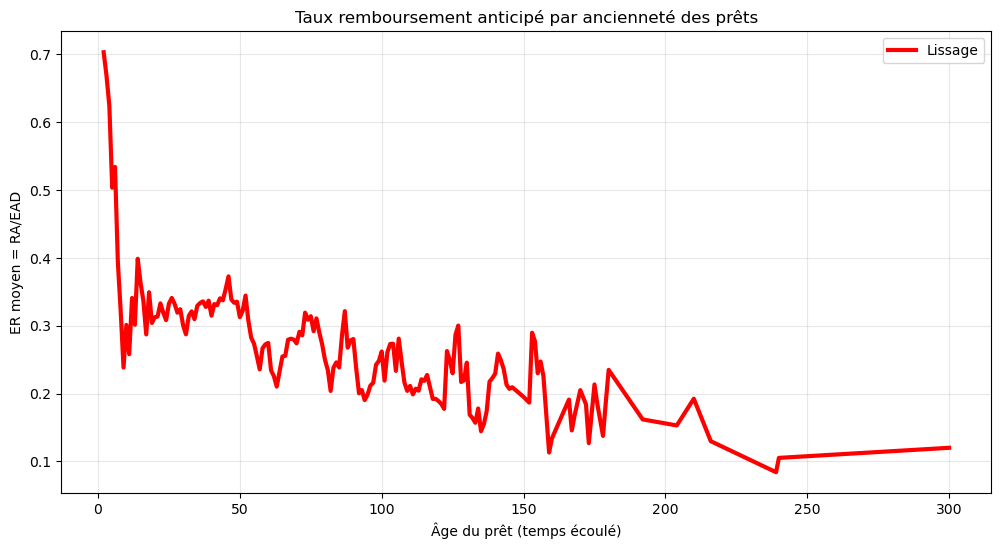

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(er_par_t['t_ecoule'], er_par_t['er_smooth'], 'r-', linewidth=3, label='Lissage')

plt.xlabel('Âge du prêt (temps écoulé)')
plt.ylabel('ER moyen = RA/EAD')
plt.title('Taux remboursement anticipé par ancienneté des prêts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
er_par_t.describe()

,t_ecoule,mean,std,count,er_smooth
count,171.000000,171.000000,158.000000,171.000000,171.000000
mean,90.725146,0.257536,0.258166,43.701754,0.263891
std,56.737065,0.132364,0.107150,145.998102,0.087681
min,2.000000,0.000000,0.000000,1.000000,0.084077
25%,44.500000,0.169469,0.199675,4.000000,0.209835
50%,87.000000,0.248799,0.275456,9.000000,0.255612
75%,130.500000,0.324495,0.317254,17.500000,0.312612
max,300.000000,0.703285,0.692878,1295.000000,0.703285


RA nettoyé: 0.0 80000.0
ER corrigé: count    7473.000000
mean        0.263071
std         0.282876
min         0.000000
25%         0.036237
50%         0.140981
75%         0.432059
max         1.000000
Name: ER, dtype: float64
% RA négatifs supprimés: 3.613006824568447 %


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\2258945714.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  er_par_t = df.groupby('t_bin')['ER'].agg(['mean', 'std', 'count']).reset_index()


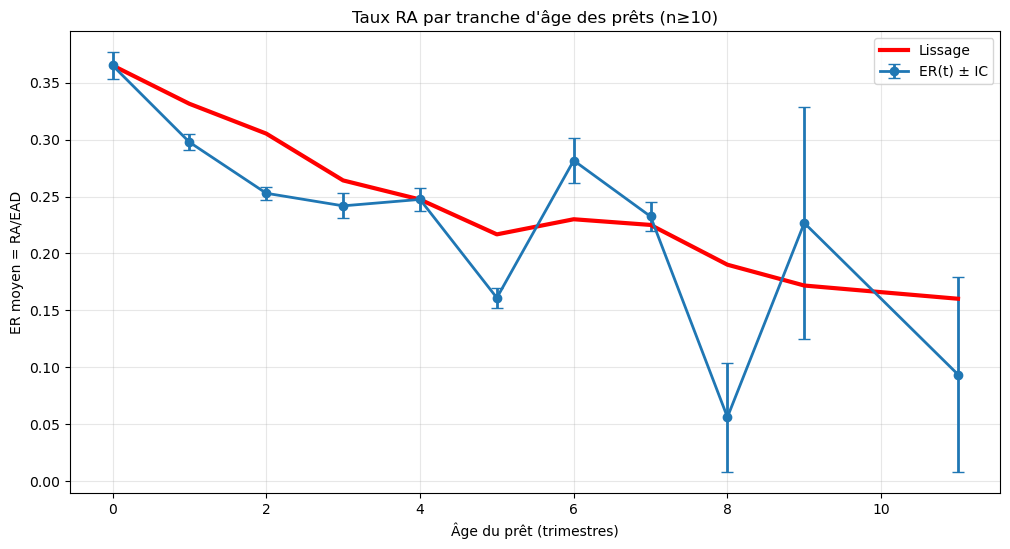

ER par bin temporel (n≥10):
   t_bin   mean    std  count  er_smooth
0      0  0.365  0.313    726      0.365
1      1  0.298  0.287   1670      0.332
2      2  0.253  0.278   2415      0.305
3      3  0.242  0.278    636      0.264
4      4  0.247  0.273    717      0.247
5      5  0.161  0.241    707      0.217
6      6  0.282  0.277    189      0.230
7      7  0.232  0.251    393      0.225
8      8  0.056  0.107      5      0.190
9      9  0.227  0.340     11      0.172
11    11  0.094  0.172      4      0.160


In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 1. NETTOYER RA négatifs
df['RA_clean'] = df['RA'].clip(lower=0)  # RA ≥ 0
print("RA nettoyé:", df['RA_clean'].min(), df['RA_clean'].max())

# 2. ER correct
df['ER'] = df['RA_clean'] / df['EAD'].clip(lower=1)
df['ER'] = df['ER'].clip(upper=1)  # ER ≤ 100%

print("ER corrigé:", df['ER'].describe())
print("% RA négatifs supprimés:", (df['RA'] < 0).mean()*100, "%")



df['t_ecoule'] = df['NB_ECH']  # ou MATURITE_TOTALE - HORIZON_RES

# 2. BINS TEMPORELS (3 mois = 10+ individus typiquement)
df['t_bin'] = pd.cut(df['t_ecoule'], 
                     bins=12,  # 12 trimestres ou 24 mois
                     labels=range(12))

# 3. AGRÉGER par bin
er_par_t = df.groupby('t_bin')['ER'].agg(['mean', 'std', 'count']).reset_index()
er_par_t['er_smooth'] = er_par_t['mean'].rolling(3, min_periods=1).mean()

# 4. FILTRER bins avec assez d'obs (>10)
er_par_t = er_par_t[er_par_t['count'] >= 4]

# 5. PLOT
plt.figure(figsize=(12, 6))
plt.errorbar(er_par_t['t_bin'], er_par_t['mean'], 
             yerr=er_par_t['std']/np.sqrt(er_par_t['count']), 
             fmt='o-', capsize=4, linewidth=2, label='ER(t) ± IC')
plt.plot(er_par_t['t_bin'], er_par_t['er_smooth'], 'r-', linewidth=3, label='Lissage')

plt.xlabel('Âge du prêt (trimestres)')
plt.ylabel('ER moyen = RA/EAD')
plt.title('Taux RA par tranche d\'âge des prêts (n≥10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. TABLEAU
print("ER par bin temporel (n≥10):")
print(er_par_t.round(3))


In [40]:
# Moins d'individus ? → Gros bins
df['t_bin'] = pd.cut(df['t_ecoule'], bins=6, labels=['6m','12m','18m','24m','30m','36m+'])

# Trop d'individus ? → Plus fin
df['t_bin'] = pd.cut(df['t_ecoule'], bins=24)  # Mensuel


C:\Users\sarah\AppData\Local\Temp\ipykernel_18872\3302422506.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  er_par_t = df.groupby('t_bin_perso')['ER'].agg(['mean', 'std', 'count']).reset_index()


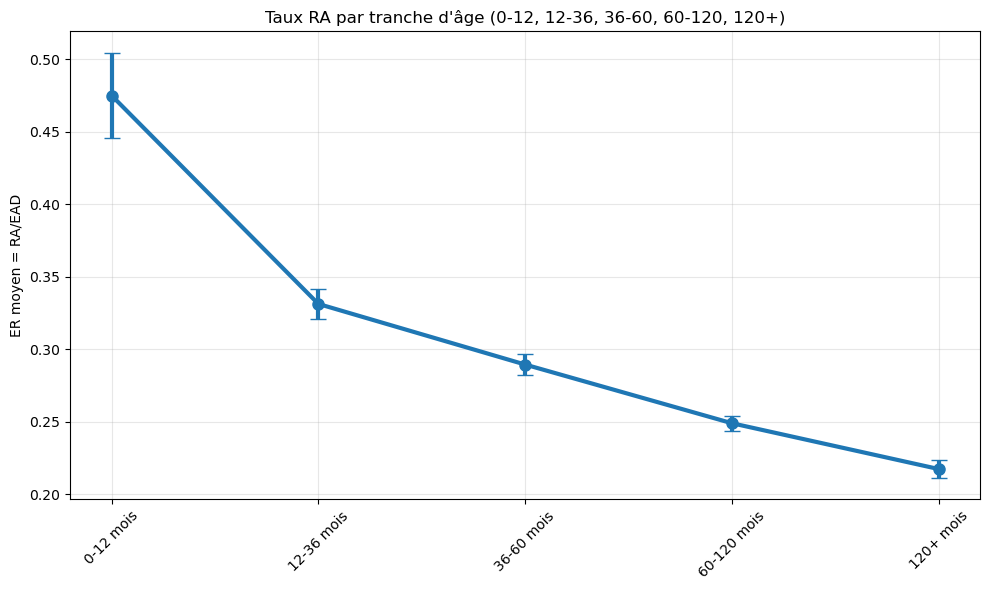

ER par tranche :
   t_bin_perso   mean    std  count
0    0-12 mois  0.475  0.371    157
1   12-36 mois  0.331  0.290    757
2   36-60 mois  0.289  0.286   1666
3  60-120 mois  0.249  0.277   3034
4    120+ mois  0.217  0.262   1859


In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Données nettoyées (déjà fait)
df['ER'] = df['RA_clean'] / df['EAD'].clip(lower=1)
df['ER'] = df['ER'].clip(upper=1)

# 2. BINS PERSO : 0-12, 12-36, 36-60, 60+
bins = [0, 12, 36, 60, 120, float('inf')]
labels = ['0-12 mois', '12-36 mois', '36-60 mois', '60-120 mois', '120+ mois']
df['t_bin_perso'] = pd.cut(df['NB_ECH'], bins=bins, labels=labels, right=False)

# 3. Agréger
er_par_t = df.groupby('t_bin_perso')['ER'].agg(['mean', 'std', 'count']).reset_index()
er_par_t = er_par_t[er_par_t['count'] >= 10]  # Min 10 obs

# 4. PLOT
plt.figure(figsize=(10, 6))
x_pos = range(len(er_par_t))
plt.errorbar(x_pos, er_par_t['mean'], 
             yerr=er_par_t['std']/np.sqrt(er_par_t['count']), 
             fmt='o-', capsize=6, linewidth=3, markersize=8)
plt.xticks(x_pos, er_par_t['t_bin_perso'], rotation=45)
plt.ylabel('ER moyen = RA/EAD')
plt.title('Taux RA par tranche d\'âge (0-12, 12-36, 36-60, 60-120, 120+)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Tableau
print("ER par tranche :")
print(er_par_t[['t_bin_perso', 'mean', 'std', 'count']].round(3))


In [42]:
df["Tx"]

71       2.302021
73       2.037189
123      2.115002
125      2.083425
135      2.180607
           ...   
99952    2.472203
99961    2.179428
99980    2.058708
99988    2.180607
99993    2.369818
Name: Tx, Length: 7473, dtype: float64

In [43]:
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + ( df["Tx"] / 1200) ) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))

In [44]:
df["Capital_emprunt"].describe()

count      7473.000000
mean      20245.989770
std       28649.887329
min          57.277652
25%        5211.097292
50%       11038.636889
75%       22723.498464
max      841957.331974
Name: Capital_emprunt, dtype: float64

In [45]:
df["Pret"] = df["MTECH"] * df["NB_ECH"]

In [46]:
df["Pret"].describe()

count      7473.000000
mean      22430.260450
std       32403.545528
min          57.510000
25%        5479.200000
50%       11746.800000
75%       24865.800000
max      861977.760000
Name: Pret, dtype: float64

Montant déjà remboursé

In [47]:
df["Montant_rembourse"] = round((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0),2)

In [48]:
df["Montant_rembourse"].describe()

count    7.473000e+03
mean     8.992799e+03
std      5.249295e+04
min      0.000000e+00
25%      1.332870e+03
50%      3.226000e+03
75%      8.676080e+03
max      4.273973e+06
Name: Montant_rembourse, dtype: float64

Montant remboursé + remboursements anticipés

In [49]:
df["Montant_plus_RA"] = df["Montant_rembourse"] + df["RA"].clip(lower=0)

In [50]:
df["Montant_plus_RA"].describe()

count    7.473000e+03
mean     1.097364e+04
std      5.267266e+04
min      0.000000e+00
25%      2.385920e+03
50%      5.296060e+03
75%      1.143360e+04
max      4.273973e+06
Name: Montant_plus_RA, dtype: float64

Montant qui n'a pas encore été remboursé

In [51]:
df["Reste_a_rembourser"] = -(df["Montant_plus_RA"] - df["Pret"])

In [52]:
df["Reste_a_rembourser"].describe()

count    7.473000e+03
mean     1.145662e+04
std      4.611000e+04
min     -3.411995e+06
25%      1.362170e+03
50%      4.964000e+03
75%      1.381488e+04
max      3.173729e+05
Name: Reste_a_rembourser, dtype: float64

Interets à payer du contrat

In [53]:
df["interets"] = df["Pret"] - df["Capital_emprunt"]

In [54]:
df["interets"].describe()

count     7473.000000
mean      2184.270680
std       4104.873560
min         -2.555473
25%        245.842513
50%        636.038464
75%       2053.101456
max      51332.911196
Name: interets, dtype: float64

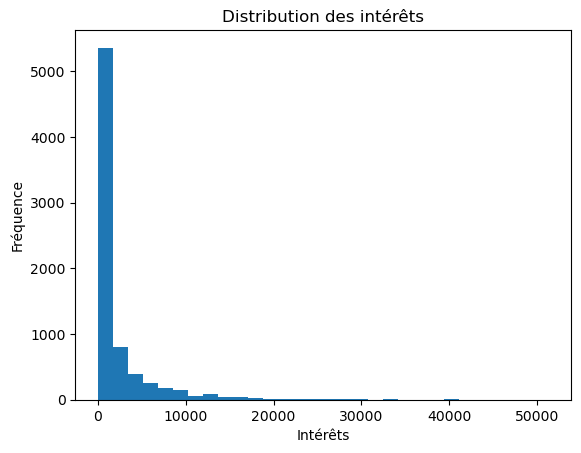

In [55]:
plt.figure()
plt.hist(df["interets"], bins=30)
plt.xlabel("Intérêts")
plt.ylabel("Fréquence")
plt.title("Distribution des intérêts")
plt.show()

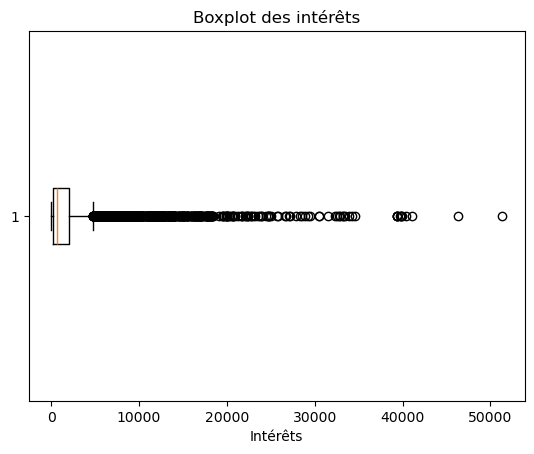

In [56]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["interets"].dropna(), vert=False)
plt.xlabel("Intérêts")
plt.title("Boxplot des intérêts")
plt.show()


In [57]:
# clusteriser par les pret a long ou court terme, et observe l'ER
# Le faire ausssi en fonction des revenus 
# Faire des arbres pour classifier ces deux variables.
# Voir aussi en fonction des capitaux empruntés et en fonction des taux, 
# pk pas voir avec les taux en france aussi 